# How editing methods actually differ


Editing looks like generation but carries a constraint generation never faces: everything you did
not ask to change has to come back unchanged. Different methods buy that property in very different
ways, and the difference is visible.

This notebook runs three of them on the same image and shows what each preserves and what it
disturbs. The point is not which scores best. It is that "preserves the background" means something
different, and something weaker, for each one.

Runs in a couple of minutes on one GPU. Outputs below are from an NVIDIA A100 80GB.


---


**What this notebook uses, and who made it**

| Component | Source |
|---|---|
| Stable Diffusion 1.5 | [runwayml/stable-diffusion-v1-5](https://huggingface.co/runwayml/stable-diffusion-v1-5) |
| SDEdit (image-to-image strength) | [Meng et al., SDEdit](https://arxiv.org/abs/2108.01073) |
| Latent masked blending (implemented inline) | the standard mask-composite trick used by [diffusers inpainting](https://github.com/huggingface/diffusers) |
| IP-Adapter reference conditioning | [h94/IP-Adapter](https://huggingface.co/h94/IP-Adapter), [tencent-ailab/IP-Adapter](https://github.com/tencent-ailab/IP-Adapter) |
| `diffusers` | [huggingface/diffusers](https://github.com/huggingface/diffusers) |

This notebook assembles released models and the authors' own code. It reimplements nothing.
Related atlas reading: [editing lines by the space they work in](/sections/editing) and
[the open problem of region preservation](/problems#edit-region-preservation).


/home/exx/anaconda3/envs/dediffusion/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda | gpu: NVIDIA A100 80GB PCIe


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading pipeline components...:  17%|█▋        | 1/6 [00:00<00:00,  5.91it/s]

Loading pipeline components...:  50%|█████     | 3/6 [00:00<00:00,  5.95it/s]

...

 57%|█████▋    | 17/30 [00:00<00:00, 28.99it/s]

 70%|███████   | 21/30 [00:00<00:00, 30.76it/s]

 83%|████████▎ | 25/30 [00:00<00:00, 32.11it/s]

 97%|█████████▋| 29/30 [00:01<00:00, 32.88it/s]

100%|██████████| 30/30 [00:01<00:00, 27.16it/s]

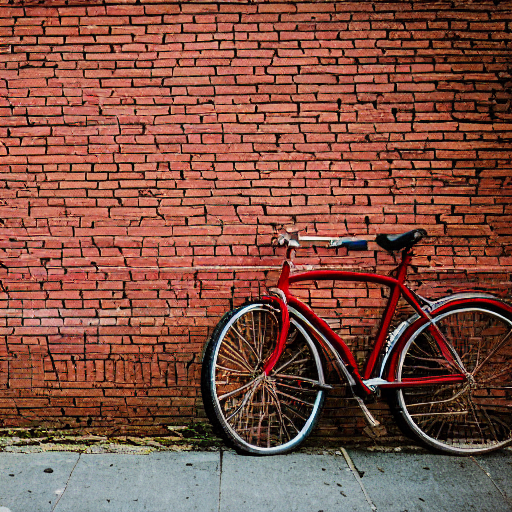

In [1]:
import torch, numpy as np, matplotlib.pyplot as plt
from PIL import Image
from diffusers import StableDiffusionPipeline

DEV = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float16 if DEV == "cuda" else torch.float32
print(f"device: {DEV}", f"| gpu: {torch.cuda.get_device_name(0)}" if DEV == "cuda" else "")

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5", torch_dtype=DTYPE,
    safety_checker=None, local_files_only=True,
).to(DEV)

# The image we will try to edit. A scene with a clear subject and a background we
# want left alone, so "did it preserve the background" is answerable by eye.
SOURCE_PROMPT = "a red vintage bicycle leaning against a brick wall, green ivy, daylight photograph"
g = torch.Generator(DEV).manual_seed(42)
source = pipe(SOURCE_PROMPT, num_inference_steps=30, generator=g).images[0]
source

## The task

We want one change: make the bicycle blue. Everything else, the brick, the ivy, the light, should be
untouched.

That is the whole difficulty. A generator asked for "a blue bicycle against a brick wall" will
happily produce a different wall.

## Method 1: regenerate from a noised version of the original (SDEdit)

The simplest approach. Add noise to the source image, then denoise it with the new prompt. The
`strength` parameter controls how much noise, which is the same as controlling how much of the
original survives.

There is no notion of a protected region here. Preservation is purely a side effect of not adding
too much noise, which is why it degrades smoothly into "a completely different picture".

In [2]:
from diffusers import StableDiffusionImg2ImgPipeline

i2i = StableDiffusionImg2ImgPipeline(**pipe.components).to(DEV)
i2i.set_progress_bar_config(disable=True)

TARGET_PROMPT = "a blue vintage bicycle leaning against a brick wall, green ivy, daylight photograph"
strengths = [0.3, 0.5, 0.7]
sdedit = []
for s in strengths:
    g = torch.Generator(DEV).manual_seed(0)
    out = i2i(prompt=TARGET_PROMPT, image=source, strength=s,
              guidance_scale=7.5, generator=g).images[0]
    sdedit.append(out)
    print(f"strength {s}: done")

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion_img2img.StableDiffusionImg2ImgPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


strength 0.3: done


strength 0.5: done


strength 0.7: done


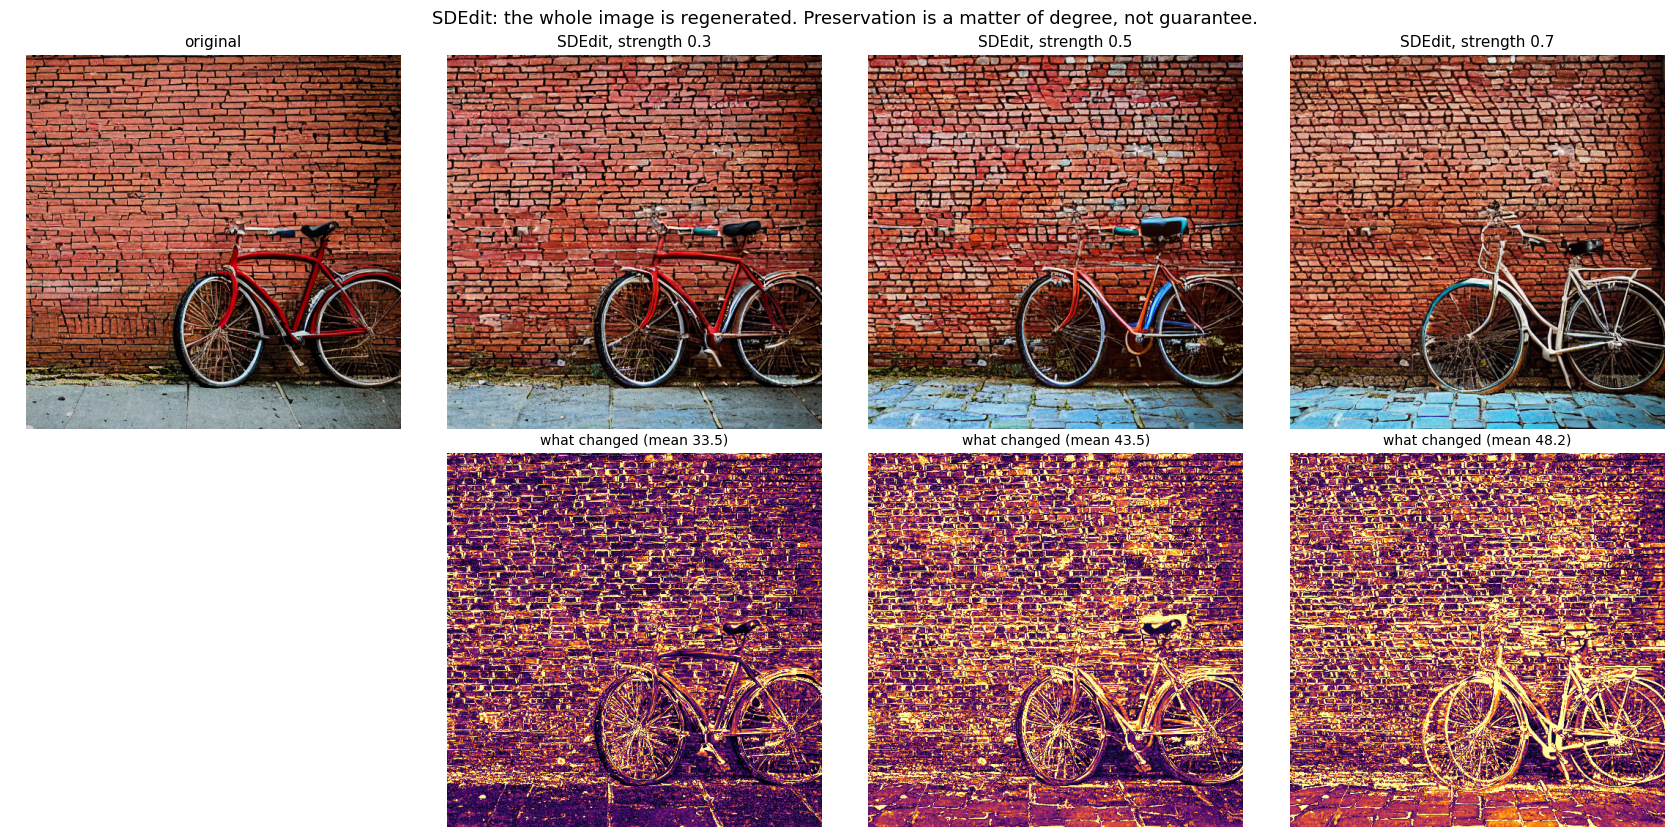

In [3]:
def diffmap(a, b):
    return np.abs(np.asarray(a, np.float64) - np.asarray(b, np.float64)).mean(axis=2)

fig, axes = plt.subplots(2, 4, figsize=(17, 8.5))
axes[0, 0].imshow(source); axes[0, 0].set_title("original", fontsize=11)
axes[1, 0].axis("off")

for i, (s, img) in enumerate(zip(strengths, sdedit), start=1):
    axes[0, i].imshow(img); axes[0, i].set_title(f"SDEdit, strength {s}", fontsize=11)
    d = diffmap(source, img)
    axes[1, i].imshow(d, cmap="inferno", vmin=0, vmax=80)
    axes[1, i].set_title(f"what changed (mean {d.mean():.1f})", fontsize=10)

for ax in axes.ravel(): ax.axis("off")
plt.suptitle("SDEdit: the whole image is regenerated. Preservation is a matter of degree, not guarantee.",
             fontsize=13)
plt.tight_layout(); plt.show()

Read the bottom row. At low strength the bicycle barely changes colour. At high strength
the colour changes but so does the brick, the ivy and the framing. There is no setting that changes
only the bicycle, because the method has no way to express "only the bicycle".

This is the weakest form of preservation, and it is what plain instruction editors inherit when they
have no explicit mechanism for it.

## Method 2: an explicit mask, enforced in the latent

Now we tell the model exactly which pixels may change. At every denoising step we overwrite the
latent outside the mask with the correctly-noised original. The edit therefore cannot touch the
background, not because the model chose well but because it was never allowed to.

We implement this directly rather than loading an inpainting checkpoint, because the mechanism is
the point and it is about fifteen lines. This is the same idea behind mask-guided methods like
MasaCtrl, and a weaker cousin of KV-Edit, which achieves the guarantee without any compositing by
freezing the background's key and value pairs.

The cost is visible: you have to know the mask, and the boundary becomes the new failure point.

In [4]:
import PIL.ImageDraw as ImageDraw

# A coarse mask over the region containing the bicycle. In practice this comes from a
# segmentation model or a user's brush stroke; we draw it to keep the notebook self-contained.
mask = Image.new("L", source.size, 0)
ImageDraw.Draw(mask).ellipse([90, 190, 430, 470], fill=255)

@torch.no_grad()
def masked_edit(prompt, image, mask_img, strength=0.8, steps=40, guidance=7.5, seed=0):
    """Denoise with the new prompt, but re-impose the original latent outside the mask
    at every step. Preservation outside the mask is exact by construction."""
    vae, unet, sched = pipe.vae, pipe.unet, pipe.scheduler
    x = torch.from_numpy(np.array(image)).float() / 127.5 - 1.0
    x = x.permute(2, 0, 1).unsqueeze(0).to(DEV, DTYPE)
    init = vae.encode(x).latent_dist.mean * vae.config.scaling_factor

    m = torch.from_numpy(np.array(mask_img.resize((init.shape[-1], init.shape[-2])))).float() / 255.0
    m = (m > 0.5).to(DEV, DTYPE)[None, None]          # 1 = may change, 0 = must be preserved

    emb = pipe._encode_prompt(prompt, DEV, 1, True, "")
    sched.set_timesteps(steps, device=DEV)
    ts = sched.timesteps[int(steps * (1 - strength)):]

    gen = torch.Generator(DEV).manual_seed(seed)
    noise = torch.randn(init.shape, generator=gen, device=DEV, dtype=DTYPE)
    lat = sched.add_noise(init, noise, ts[:1])

    for t in ts:
        inp = sched.scale_model_input(torch.cat([lat] * 2), t)
        uncond, cond = unet(inp, t, encoder_hidden_states=emb).sample.chunk(2)
        lat = sched.step(uncond + guidance * (cond - uncond), t, lat).prev_sample
        # the guarantee: outside the mask, snap back to the original latent at this noise level
        keep = sched.add_noise(init, noise, t.reshape(1))
        lat = lat * m + keep * (1 - m)

    out = vae.decode(lat / vae.config.scaling_factor).sample
    out = ((out.float().clamp(-1, 1) + 1) * 127.5).round().byte()
    return Image.fromarray(out.squeeze(0).permute(1, 2, 0).cpu().numpy())

inpainted = masked_edit("a blue vintage bicycle leaning against a brick wall", source, mask)
print("masked edit done")

/home/exx/anaconda3/envs/dediffusion/lib/python3.11/site-packages/diffusers/pipelines/stable_diffusion/pipeline_stable_diffusion.py:313: FutureWarning: `_encode_prompt()` is deprecated and it will be removed in a future version. Use `encode_prompt()` instead. Also, be aware that the output format changed from a concatenated tensor to a tuple.
  deprecate("_encode_prompt()", "1.0.0", deprecation_message, standard_warn=False)


masked edit done


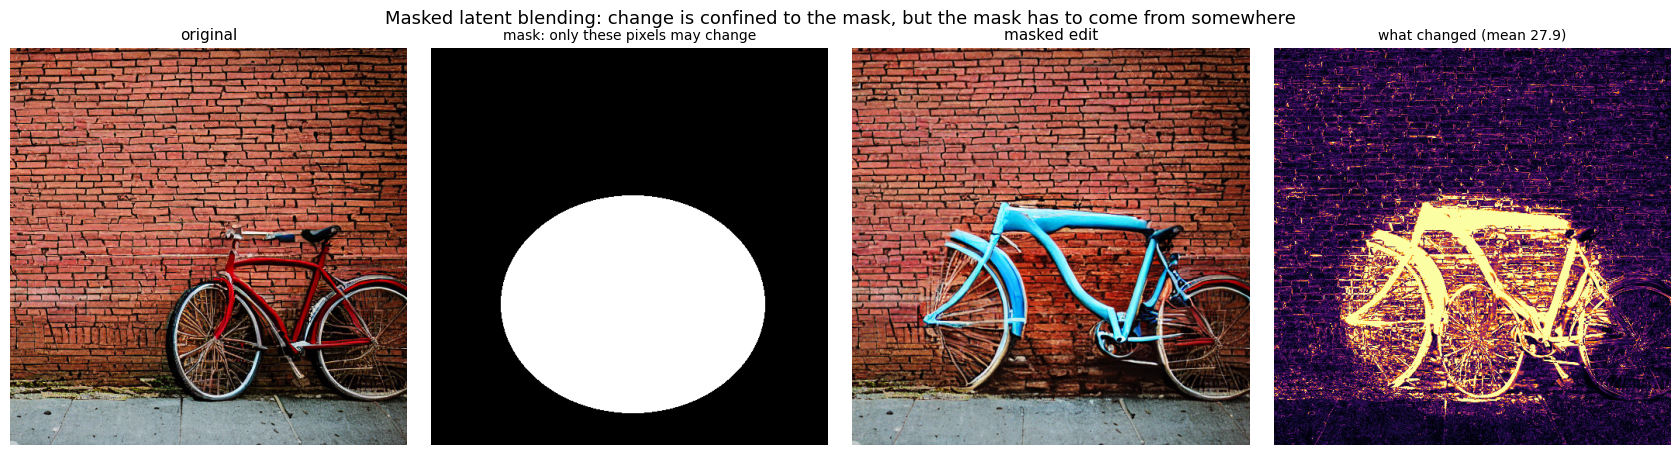

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(17, 4.6))
axes[0].imshow(source);   axes[0].set_title("original", fontsize=11)
axes[1].imshow(mask, cmap="gray"); axes[1].set_title("mask: only these pixels may change", fontsize=10)
axes[2].imshow(inpainted); axes[2].set_title("masked edit", fontsize=11)
d = diffmap(source, inpainted)
axes[3].imshow(d, cmap="inferno", vmin=0, vmax=80)
axes[3].set_title(f"what changed (mean {d.mean():.1f})", fontsize=10)
for ax in axes: ax.axis("off")
plt.suptitle("Masked latent blending: change is confined to the mask, but the mask has to come from somewhere",
             fontsize=13)
plt.tight_layout(); plt.show()

The difference map is now black outside the mask. Not nearly black: black. That is what
an architectural guarantee looks like, as opposed to a statistical tendency.

This is the same property that [KV-Edit](/papers/kv-edit-2025) achieves without needing the pixels
composited back, by freezing the background tokens' key and value pairs so unedited content never
re-enters the generative process at all.

## Method 3: conditioning on a reference image (IP-Adapter)

The third pattern does not edit at all. It conditions a fresh generation on a reference image
through a second, parallel cross-attention path, leaving the text path untouched.

This is how reference-driven and identity-preserving methods work. It is worth including here
because it is frequently described as editing and is a different thing: nothing is preserved,
because nothing is being modified. The reference only steers.

In [6]:
ok = True
try:
    ip = StableDiffusionPipeline.from_pretrained(
        "runwayml/stable-diffusion-v1-5", torch_dtype=DTYPE,
        safety_checker=None, local_files_only=True,
    ).to(DEV)
    ip.load_ip_adapter("h94/IP-Adapter", subfolder="models",
                       weight_name="ip-adapter_sd15.bin", local_files_only=True)
    ip.set_ip_adapter_scale(0.7)
    ip.set_progress_bar_config(disable=True)
    g = torch.Generator(DEV).manual_seed(0)
    ref_out = ip("a bicycle in a sunlit meadow, photograph",
                 ip_adapter_image=source, num_inference_steps=30, generator=g).images[0]
except Exception as e:
    ok = False
    print(f"IP-Adapter weights not available locally: {type(e).__name__}: {e}")
    print("Skipping this section; the two methods above are unaffected.")

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading pipeline components...:  50%|█████     | 3/6 [00:00<00:00,  5.05it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   1%|          | 1/196 [00:00<00:00, 1488.93it/s, Materializing param=text_model.embeddings.position_embedding.weight]

Loading weights:   1%|          | 1/196 [00:00<00:00, 442.44it/s, Materializing param=text_model.embeddings.position_embedding.weight] 

...

Loading weights: 100%|█████████▉| 519/520 [00:01<00:00, 460.53it/s, Materializing param=vision_model.pre_layrnorm.weight]

Loading weights: 100%|██████████| 520/520 [00:01<00:00, 460.53it/s, Materializing param=visual_projection.weight]        

Loading weights: 100%|██████████| 520/520 [00:01<00:00, 460.53it/s, Materializing param=visual_projection.weight]

Loading weights: 100%|██████████| 520/520 [00:01<00:00, 290.85it/s, Materializing param=visual_projection.weight]

CLIPVisionModelWithProjection LOAD REPORT from: h94/IP-Adapter
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


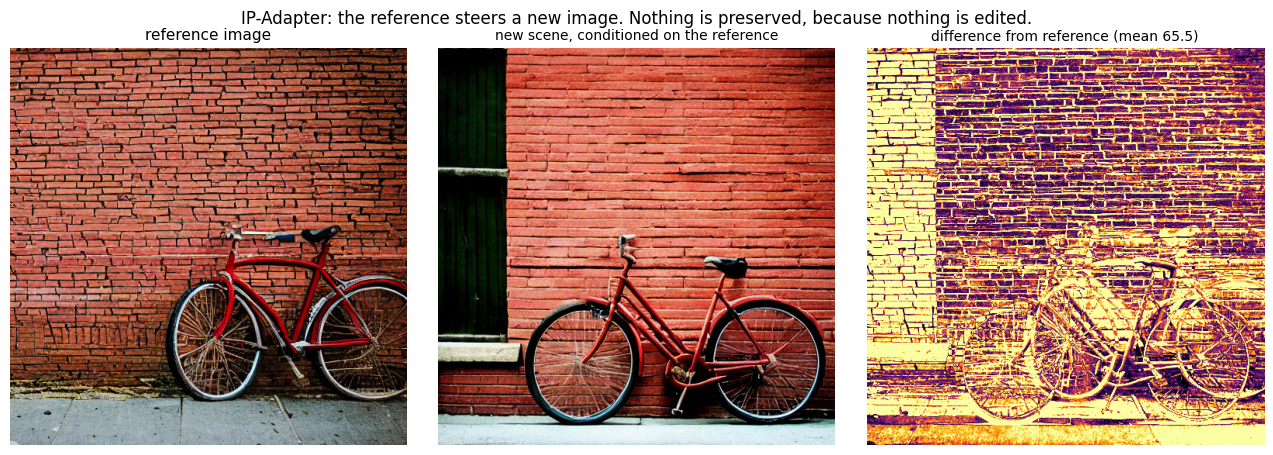

In [7]:
if ok:
    fig, axes = plt.subplots(1, 3, figsize=(13, 4.6))
    axes[0].imshow(source);  axes[0].set_title("reference image", fontsize=11)
    axes[1].imshow(ref_out); axes[1].set_title("new scene, conditioned on the reference", fontsize=10)
    d = diffmap(source, ref_out)
    axes[2].imshow(d, cmap="inferno", vmin=0, vmax=80)
    axes[2].set_title(f"difference from reference (mean {d.mean():.1f})", fontsize=10)
    for ax in axes: ax.axis("off")
    plt.suptitle("IP-Adapter: the reference steers a new image. Nothing is preserved, because nothing is edited.",
                 fontsize=12)
    plt.tight_layout(); plt.show()
else:
    print("skipped")

## What to take away

The three methods sit at different points on one axis: how strongly is unedited content protected?

| Method | Preservation mechanism | Guarantee |
|---|---|---|
| SDEdit | add less noise | none, only a dial |
| Masked latent blending | re-impose the original latent outside the mask each step | exact, but you need the mask |
| IP-Adapter | not applicable | nothing is preserved; a reference steers a new image |

Modern instruction editors like [FLUX.1 Kontext](/papers/kontext-2025) and
[Qwen-Image-Edit](/papers/qwen-image-2025) sit closer to the first row than people expect. They learn
preservation from training data rather than enforcing it, which is why Kontext's own paper concedes
character drift across multiple turns, and why Qwen shipped a dedicated identity-preservation reward
head rather than relying on architecture.

The methods with real guarantees are the ones that never let unedited content back into the
generative process. That is the argument laid out on
[the editing section](/sections/editing) and tracked as
[an open problem](/problems#edit-region-preservation).